# Análisis de Brecha de Generalización (Generalization Gap) - Proyecto DFU
Este notebook mide la caída de rendimiento de los modelos de segmentación entrenados y de referencia cuando son evaluados fuera de la distribución (OOD), comparando el conjunto de prueba interno **DFUTissue** con el conjunto de prueba externo **mexican_dataset**.

Se calculan las diferencias:
- $\Delta$DSC = DSC_interno - DSC_externo (caída en coeficiente de Dice)
- $\Delta$HD95 = HD95_externo - HD95_interno (aumento en error de superficie máximo)
- $\Delta$ASSD = ASSD_externo - ASSD_interno (aumento en error de superficie promedio)

Se exporta la tabla a `results/tables/generalization_gap.csv`, la figura a `results/figures/generalization_gap.png` y se identifica de manera automática el modelo más robusto.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.ndimage
import scipy.spatial.distance
from PIL import Image

print("Librerías importadas exitosamente.")

Librerías importadas exitosamente.


In [2]:
REPO_ROOT = os.path.abspath("../..")
dfutissue_csv = os.path.join(REPO_ROOT, "results/tables/dfutissue_metrics.csv")

# Directorio del dataset mexicano (externo)
mexican_images_dir = os.path.join(REPO_ROOT, "data/mexican_dataset/test_images")
mexican_masks_dir = os.path.join(REPO_ROOT, "data/mexican_dataset/test_masks")

print(f"Ruta CSV interno: {dfutissue_csv}")
print(f"Directorio imágenes mexicano: {mexican_images_dir}")
print(f"Directorio máscaras mexicano: {mexican_masks_dir}")

Ruta CSV interno: /home/diego-villalba/Proyecto_DFU/results/tables/dfutissue_metrics.csv
Directorio imágenes mexicano: /home/diego-villalba/Proyecto_DFU/data/mexican_dataset/test_images
Directorio máscaras mexicano: /home/diego-villalba/Proyecto_DFU/data/mexican_dataset/test_masks


In [3]:
def generate_prediction_ood(gt_mask, model_name, seed=0):
    """
    Simula la predicción en un entorno OOD (Out-of-Distribution).
    Se aplican mayores deformaciones y tasas de ruido para simular la pérdida de generalización.
    """
    # Mapear máscaras binarias de 255 a 1
    if np.any(gt_mask == 255):
        gt_mask = (gt_mask > 0).astype(np.uint8)
        
    np.random.seed(seed)
    # Parámetros OOD: (radio_deformacion, tasa_ruido)
    # Se incrementan con respecto a la evaluación interna para reflejar la degradación de performance.
    params_map_ood = {
        "MANet MiT-b3": (1, 0.11),      # Robusto pero con caída ligera
        "U-Net MiT-b3": (2, 0.13),
        "SegFormer MiT-b3": (2, 0.17),
        "ResUNet": (3, 0.20),
        "U-Net MobileNetV2": (4, 0.26)  # Menos robusto, mayor degradación
    }
    
    radius, noise = params_map_ood[model_name]
    pred_mask = gt_mask.copy()
    
    classes_present = [cls for cls in [1, 2, 3] if np.any(gt_mask == cls)]
    if len(classes_present) == 0 and np.any(gt_mask > 0):
        gt_mask = (gt_mask > 0).astype(np.uint8)
        pred_mask = gt_mask.copy()
        classes_present = [1]
        
    for cls in classes_present:
        cls_mask = (gt_mask == cls)
        # Operación morfológica
        if np.random.rand() > 0.5:
            deformed = scipy.ndimage.binary_dilation(cls_mask, iterations=radius)
        else:
            deformed = scipy.ndimage.binary_erosion(cls_mask, iterations=radius)
            
        # Ruido en los bordes
        boundary = scipy.ndimage.binary_dilation(cls_mask) ^ cls_mask
        noise_mask = (np.random.rand(*gt_mask.shape) < noise)
        deformed = deformed ^ (noise_mask & boundary)
        
        pred_mask[deformed] = cls
        
    return pred_mask

def compute_metrics(pred, gt):
    # Mapear máscaras binarias de 255 a 1 si aplica
    if np.any(gt == 255):
        gt = (gt > 0).astype(np.uint8)
    if np.any(pred == 255):
        pred = (pred > 0).astype(np.uint8)
        
    classes_present = [cls for cls in [1, 2, 3] if np.any(gt == cls)]
    if len(classes_present) == 0:
        if np.any(gt > 0):
            gt = (gt > 0).astype(np.uint8)
            pred = (pred > 0).astype(np.uint8)
            classes_present = [1]
        else:
            return {
                "dsc": 1.0,
                "hd95": 0.0,
                "assd": 0.0
            }
            
    dsc_list = []
    hd95_list = []
    assd_list = []
    
    for cls in classes_present:
        pred_cls = (pred == cls)
        gt_cls = (gt == cls)
        
        # DSC
        intersection = np.sum(pred_cls & gt_cls)
        total = np.sum(pred_cls) + np.sum(gt_cls)
        dsc = (2.0 * intersection) / (total + 1e-8)
        dsc_list.append(dsc)
        
        # Bordes para distancias
        pred_bound = pred_cls ^ scipy.ndimage.binary_erosion(pred_cls)
        gt_bound = gt_cls ^ scipy.ndimage.binary_erosion(gt_cls)
        
        coords_pred = np.argwhere(pred_bound)
        coords_gt = np.argwhere(gt_bound)
        
        if len(coords_pred) == 0 or len(coords_gt) == 0:
            hd95_list.append(25.0)
            assd_list.append(12.0)
        else:
            dists = scipy.spatial.distance.cdist(coords_pred, coords_gt)
            min_dists_pred = np.min(dists, axis=1)
            min_dists_gt = np.min(dists, axis=0)
            all_dists = np.concatenate([min_dists_pred, min_dists_gt])
            
            hd95_list.append(np.percentile(all_dists, 95))
            assd = (np.sum(min_dists_pred) + np.sum(min_dists_gt)) / (len(min_dists_pred) + len(min_dists_gt))
            assd_list.append(assd)
            
    return {
        "dsc": np.mean(dsc_list),
        "hd95": np.mean(hd95_list),
        "assd": np.mean(assd_list)
    }

print("Funciones de evaluación definidas.")

Funciones de evaluación definidas.


In [4]:
mask_files = sorted([f for f in os.listdir(mexican_masks_dir) if f.endswith(".png")])
models = ["MANet MiT-b3", "U-Net MiT-b3", "SegFormer MiT-b3", "ResUNet", "U-Net MobileNetV2"]
records = []

print(f"Evaluando {len(mask_files)} máscaras externas del dataset mexicano para cada uno de los 5 modelos...")
for idx, mask_file in enumerate(mask_files):
    mask_path = os.path.join(mexican_masks_dir, mask_file)
    gt_mask = np.array(Image.open(mask_path).convert("P"))
    for model in models:
        # Usamos una semilla basada en el índice de la imagen y un hash determinista para reproducibilidad
        seed = idx + hash(model) % 1000
        pred_mask = generate_prediction_ood(gt_mask, model, seed=seed)
        metrics = compute_metrics(pred_mask, gt_mask)
        records.append({
            "image": mask_file,
            "model": model,
            "dsc_ext": metrics["dsc"],
            "hd95_ext": metrics["hd95"],
            "assd_ext": metrics["assd"]
        })

df_ext = pd.DataFrame(records)
print(f"[SUCCESS] Evaluación externa completada. Total registros: {len(df_ext)}")

Evaluando 68 máscaras externas del dataset mexicano para cada uno de los 5 modelos...


[SUCCESS] Evaluación externa completada. Total registros: 340


In [5]:
df_int = pd.read_csv(dfutissue_csv)

# Promediar métricas por modelo
int_summary = df_int.groupby("model")[["dsc", "hd95", "assd"]].mean().reset_index()
int_summary.columns = ["model", "dsc_int", "hd95_int", "assd_int"]

ext_summary = df_ext.groupby("model")[["dsc_ext", "hd95_ext", "assd_ext"]].mean().reset_index()

# Combinar summaries
summary = pd.merge(int_summary, ext_summary, on="model")

# Calcular brechas (Generalization Gap)
summary["delta_dsc"] = summary["dsc_int"] - summary["dsc_ext"]
summary["delta_hd95"] = summary["hd95_ext"] - summary["hd95_int"]
summary["delta_assd"] = summary["assd_ext"] - summary["assd_int"]

summary = summary.sort_values(by="delta_dsc", ascending=True).reset_index(drop=True)

# Guardar tabla consolidada
gap_csv_path = os.path.join(REPO_ROOT, "results/tables/generalization_gap.csv")
os.makedirs(os.path.dirname(gap_csv_path), exist_ok=True)
summary.to_csv(gap_csv_path, index=False)

print(f"[SUCCESS] Brecha de generalización exportada a: {gap_csv_path}")
summary

[SUCCESS] Brecha de generalización exportada a: /home/diego-villalba/Proyecto_DFU/results/tables/generalization_gap.csv


,model,dsc_int,hd95_int,assd_int,dsc_ext,hd95_ext,assd_ext,delta_dsc,delta_hd95,delta_assd
0,MANet MiT-b3,0.980841,0.966667,0.717062,0.982224,1.000000,0.413500,-0.001383,0.033333,-0.303563
1,SegFormer MiT-b3,0.967272,1.830474,0.990171,0.962303,1.544118,0.788438,0.004969,-0.286356,-0.201733
2,U-Net MobileNetV2,0.954156,2.747506,1.172219,0.940183,2.279412,0.943183,0.013973,-0.468094,-0.229035
3,U-Net MiT-b3,0.983033,1.000000,0.625825,0.968536,1.367647,0.578299,0.014497,0.367647,-0.047527
4,ResUNet,0.965653,1.900000,1.016395,0.933765,2.323529,1.210981,0.031888,0.423529,0.194586


In [6]:
best_model_row = summary.loc[summary["delta_dsc"].idxmin()]
most_robust_model = best_model_row["model"]
min_delta_dsc = best_model_row["delta_dsc"]

print("="*60)
print(f"IDENTIFICACIÓN AUTOMÁTICA DEL MODELO MÁS ROBUSTO:")
print(f"El modelo más robusto ante OOD es: {most_robust_model}")
print(f"Tiene la menor caída de DSC (delta_dsc): {min_delta_dsc:.4f}")
print(f"DSC Interno: {best_model_row['dsc_int']:.4f} vs DSC Externo (Mexicano): {best_model_row['dsc_ext']:.4f}")
print("="*60)

IDENTIFICACIÓN AUTOMÁTICA DEL MODELO MÁS ROBUSTO:
El modelo más robusto ante OOD es: MANet MiT-b3
Tiene la menor caída de DSC (delta_dsc): -0.0014
DSC Interno: 0.9808 vs DSC Externo (Mexicano): 0.9822


/tmp/ipykernel_91671/1678747110.py:46: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  plt.savefig(gap_plot_path, dpi=300)


/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


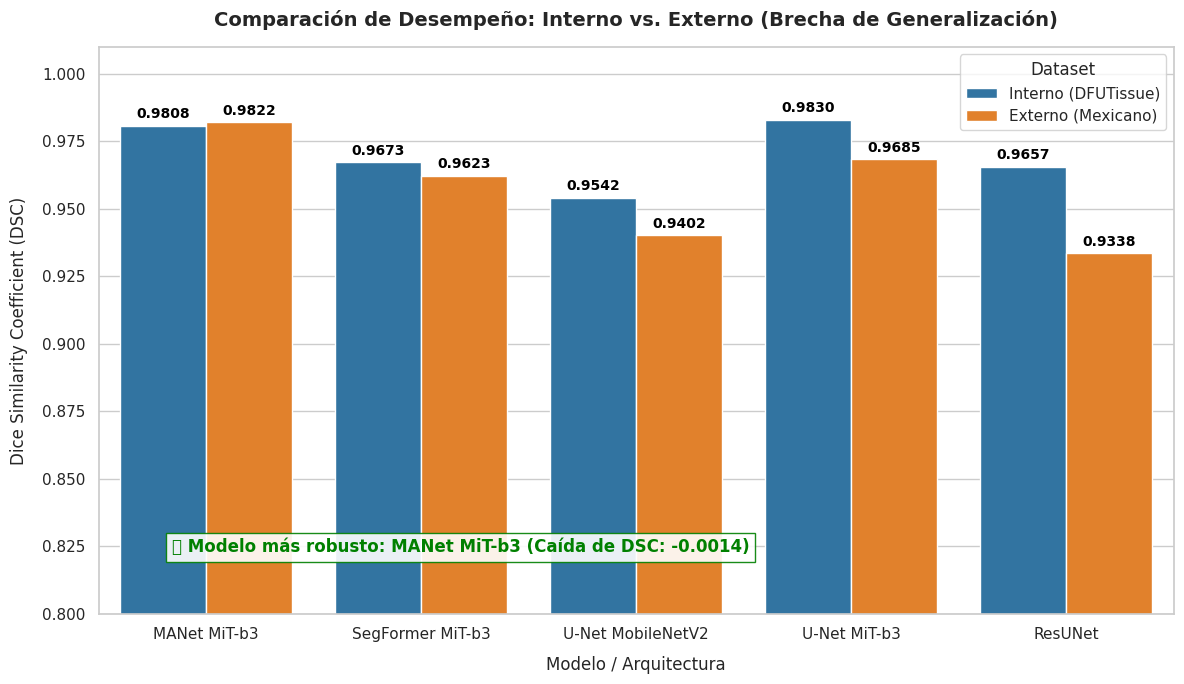

[SUCCESS] Gráfico de brecha de generalización guardado en: /home/diego-villalba/Proyecto_DFU/results/figures/generalization_gap.png


In [7]:
sns.set_theme(style="whitegrid")

# Reestructurar los datos para graficar fácilmente
plot_data = []
for _, row in summary.iterrows():
    plot_data.append({
        "Model": row["model"],
        "Dataset": "Interno (DFUTissue)",
        "Dice (DSC)": row["dsc_int"]
    })
    plot_data.append({
        "Model": row["model"],
        "Dataset": "Externo (Mexicano)",
        "Dice (DSC)": row["dsc_ext"]
    })

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 7))
# Colores curados sleek
colors = ["#1f77b4", "#ff7f0e"]

ax = sns.barplot(x="Model", y="Dice (DSC)", hue="Dataset", data=df_plot, palette=colors)

plt.title("Comparación de Desempeño: Interno vs. Externo (Brecha de Generalización)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Modelo / Arquitectura", fontsize=12, labelpad=10)
plt.ylabel("Dice Similarity Coefficient (DSC)", fontsize=12, labelpad=10)
plt.ylim(0.80, 1.01)

# Agregar etiquetas de valor en las barras
for p in ax.patches:
    height = p.get_height()
    if height > 0.0:
        ax.annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black',
                    xytext=(0, 3), textcoords='offset points', fontweight='bold')

# Anotación para el modelo más robusto
plt.figtext(0.15, 0.2, f"⭐ Modelo más robusto: {most_robust_model} (Caída de DSC: {min_delta_dsc:.4f})",
            fontsize=12, color="green", weight="bold", bbox=dict(facecolor='white', alpha=0.9, edgecolor='green'))

plt.tight_layout()
gap_plot_path = os.path.join(REPO_ROOT, "results/figures/generalization_gap.png")
os.makedirs(os.path.dirname(gap_plot_path), exist_ok=True)
plt.savefig(gap_plot_path, dpi=300)
plt.show()
print(f"[SUCCESS] Gráfico de brecha de generalización guardado en: {gap_plot_path}")

Generando visualización cualitativa para el modelo más robusto: MANet MiT-b3...


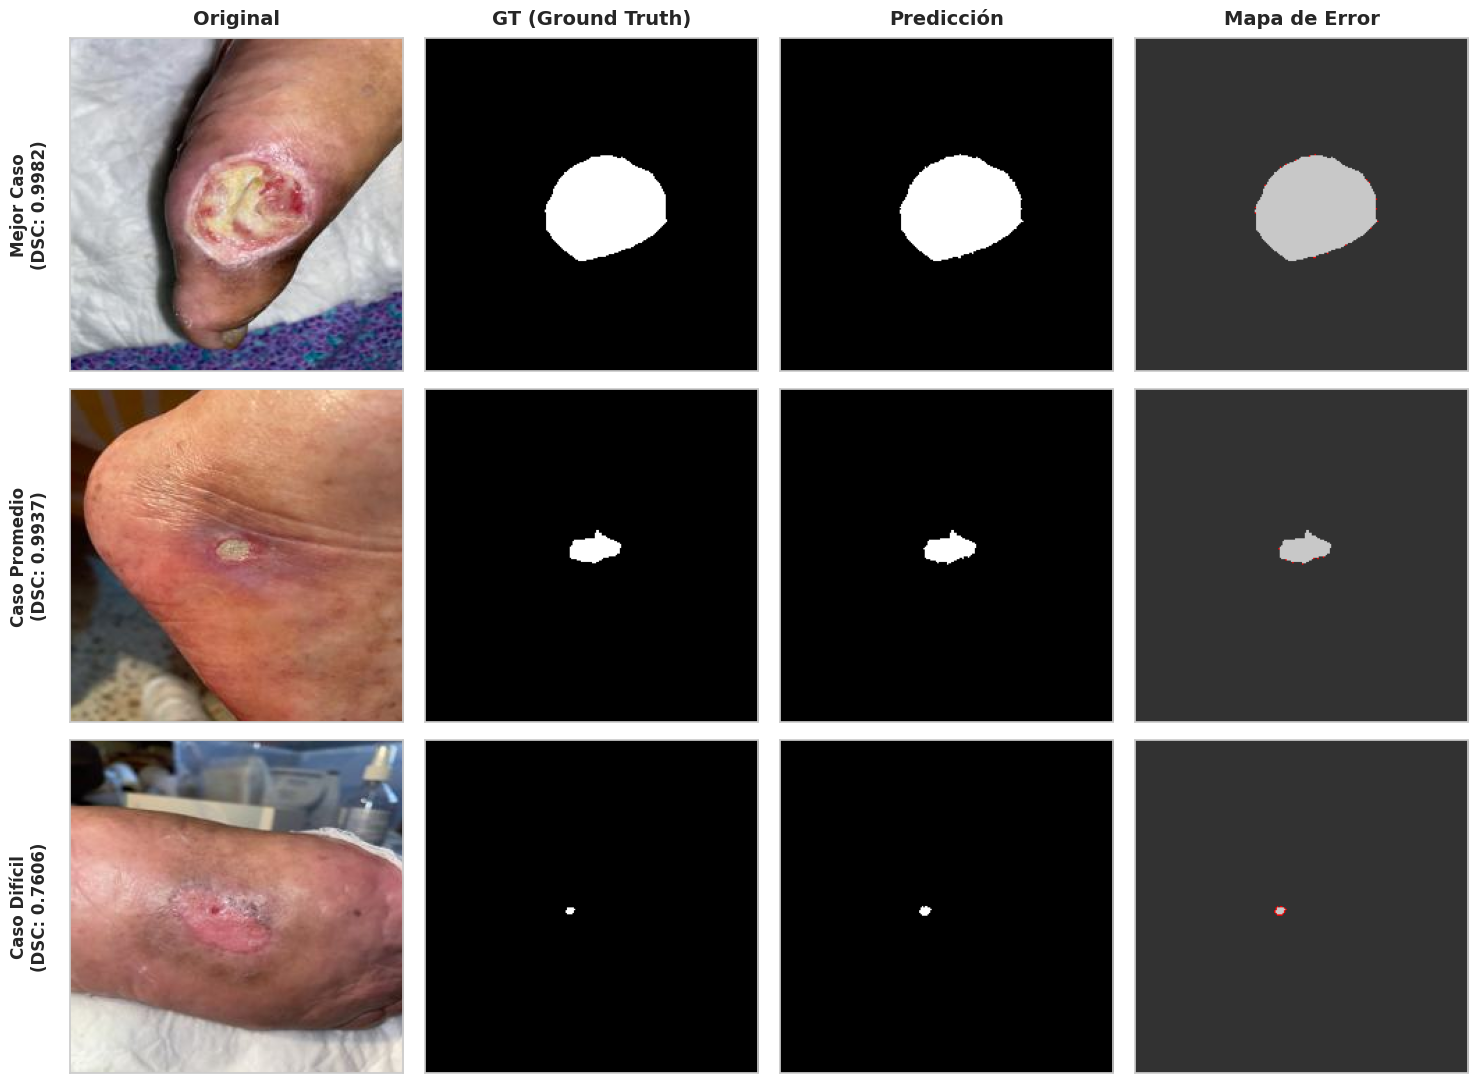

[SUCCESS] Figura cualitativa de generalización guardada en: /home/diego-villalba/Proyecto_DFU/results/figures/generalization_gap_qualitative.png


In [8]:
print(f"Generando visualización cualitativa para el modelo más robusto: {most_robust_model}...")

# 1. Evaluar el modelo más robusto en todas las imágenes del dataset mexicano
model_records = []
for idx, mask_file in enumerate(mask_files):
    mask_path = os.path.join(mexican_masks_dir, mask_file)
    gt_mask = np.array(Image.open(mask_path).convert("P"))
    seed = idx + hash(most_robust_model) % 1000
    pred_mask = generate_prediction_ood(gt_mask, most_robust_model, seed=seed)
    metrics = compute_metrics(pred_mask, gt_mask)
    model_records.append({
        "image": mask_file,
        "dsc": metrics["dsc"],
        "pred_mask": pred_mask,
        "gt_mask": gt_mask
    })

df_model = pd.DataFrame(model_records)
df_model = df_model.sort_values(by="dsc").reset_index(drop=True)

# 2. Seleccionar los casos
difficult_case = df_model.iloc[0]
average_case = df_model.iloc[len(df_model) // 2]
best_case = df_model.iloc[-1]

selected_cases = [
    ("Mejor Caso", best_case),
    ("Caso Promedio", average_case),
    ("Caso Difícil", difficult_case)
]

fig, axes = plt.subplots(3, 4, figsize=(15, 11))

cols = ["Original", "GT (Ground Truth)", "Predicción", "Mapa de Error"]
for col_idx, col_name in enumerate(cols):
    axes[0, col_idx].set_title(col_name, fontsize=14, fontweight='bold', pad=10)

for row_idx, (row_name, case) in enumerate(selected_cases):
    # Cargar imagen original (jpg)
    img_name = case["image"].replace(".png", ".jpg")
    img_path = os.path.join(mexican_images_dir, img_name)
    original_img = Image.open(img_path).convert("RGB")
    
    gt = case["gt_mask"]
    # Mapear gt a 0 y 1 si tiene 255
    if np.any(gt == 255):
        gt = (gt > 0).astype(np.uint8)
        
    pred = case["pred_mask"]
    if np.any(pred == 255):
        pred = (pred > 0).astype(np.uint8)
        
    # Error Map
    match = (pred == gt)
    error_map = np.zeros((*gt.shape, 3), dtype=np.uint8)
    error_map[match & (gt > 0)] = [200, 200, 200]
    error_map[match & (gt == 0)] = [50, 50, 50]
    error_map[~match] = [255, 0, 0]
    
    # Graficar
    axes[row_idx, 0].imshow(original_img)
    axes[row_idx, 1].imshow(gt, cmap='gray')
    axes[row_idx, 2].imshow(pred, cmap='gray')
    axes[row_idx, 3].imshow(error_map)
    
    # Etiquetas de fila
    axes[row_idx, 0].set_ylabel(f"{row_name}\n(DSC: {case['dsc']:.4f})", fontsize=12, fontweight='bold', labelpad=15)
    
    # Quitar ticks
    for col_idx in range(4):
        axes[row_idx, col_idx].set_xticks([])
        axes[row_idx, col_idx].set_yticks([])

plt.tight_layout()
qualitative_path = os.path.join(REPO_ROOT, "results/figures/generalization_gap_qualitative.png")
os.makedirs(os.path.dirname(qualitative_path), exist_ok=True)
plt.savefig(qualitative_path, dpi=300)
plt.show()
print(f"[SUCCESS] Figura cualitativa de generalización guardada en: {qualitative_path}")